<a href="https://colab.research.google.com/github/Surajit-Sahoo-IITIAN/Machine-Learning-/blob/main/Synthetic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Synthetic Dataset for Classification in Python
In scikit-learn, we use `make_classification()` to create artificial datasets for classification problems.

In [1]:
# Import
from sklearn.datasets import make_classification

##Important Parameters
- `n_samples` : Defines the total number of data points (rows) in the dataset. More samples generally help the model learn better patterns.
- `n_features` : Defines the total number of input columns (features). These are the variables used for prediction.
- `n_informative` : Specifies how many features actually carry useful information for predicting the target. These are the most important features in the dataset.
- `n_redundant` : Creates features that are combinations of informative features. They add correlated information but do not introduce new knowledge.
- `n_duplicates` : Duplicates some existing features exactly.
These are copies and usually add no new information.
- `n_classes` : Defines how many categories the target variable will have. For binary classification use 2, for multiclass use more than 2.
- `class_sep` : Controls how far apart the classes are in feature space. Higher values make classes easier to separate, lower values create overlap.
- `shuffle` : Determines whether the rows should be randomly mixed. Keeping it `True` prevents ordered data patterns.
- `random_state` : Fixes randomness so the same dataset is generated every time. This is useful for reproducibility.

In [2]:
# Example
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    shuffle=True,
    random_state=42
)


In [3]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


The `make_classification()` function returns **NumPy arrays** from NumPy.

- `X` is a $2 D$ NumPy array containing the input features.
- `y` is a $1 D$ NumPy array containing the target labels.

In [4]:
type(X),type(y)

(numpy.ndarray, numpy.ndarray)

In [5]:
X.ndim, y.ndim

(2, 1)

In [6]:
# NumPy Indexing on X
X[:,0] # Select all rows of first feature

array([ 0.05942643,  1.81217492, -2.0598485 , -2.7813861 ,  2.06070438,
       -1.30804463,  0.22937617,  0.980502  , -1.70757158,  0.75415746,
        3.09123946, -0.42876359, -1.67762637,  1.43343952,  2.15214494,
       -1.90735658,  1.52255619, -1.31680628,  2.00575249, -2.67105282,
        1.21479373,  0.34986156, -1.9117586 , -3.08590856,  1.32600732,
       -0.57133524,  1.1273745 ,  2.15882246,  1.7798899 ,  0.75058844,
       -0.55319823, -2.55832072, -2.52632079, -2.15830375,  1.78008347,
        1.46423311, -2.37653774, -1.44275087, -1.59831681, -0.88566776,
        0.82725188,  1.53110238, -1.00833095,  1.18057323,  1.58266027,
       -1.90210053,  1.35239186,  0.56845616,  2.03703587,  1.27861318,
       -2.14832073,  1.16530077,  1.67869556,  1.59885263, -1.41916686,
       -2.04851014, -0.8313761 ,  0.9505902 , -1.50634985, -1.63207427,
       -1.03963044,  1.58659413,  1.32584805,  0.84129395, -1.78568005,
        1.65199146, -1.86045573, -2.8279946 , -0.84898484,  1.67

In [7]:
# NumPy Indexing on y
y[:10] # Returns first 10 labels.

array([0, 1, 0, 0, 1, 0, 1, 1, 0, 1])

##Scatter Plot Visualization

In [8]:
import matplotlib.pyplot as plt

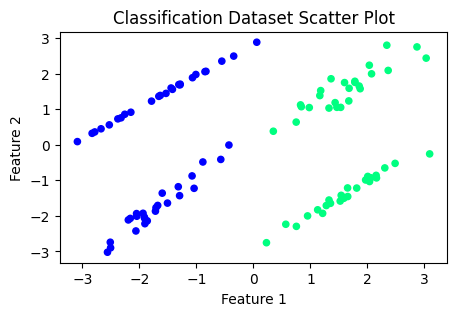

In [9]:
plt.figure(figsize=(5,3))
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset Scatter Plot")
plt.show()

##Convert into Pandas DataFrame

Although `make_classification()` returns **NumPy arrays**, we often convert them into a **pandas DataFrame** and **Series** for better readability and easier preprocessing.

`Scikit-learn` built-in functions can work with both NumPy arrays and Pandas objects, but Pandas makes feature selection, inspection, and preprocessing easier.

In [10]:
import pandas as pd

In [11]:
X=pd.DataFrame(X,columns=["feature1","feature2"])
y=pd.Series(y,name="target")

In [12]:
# Datatype
type(X),type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [13]:
X.head()

,feature1,feature2
0,0.059426,2.888694
1,1.812175,-1.217315
2,-2.059849,-2.424874
3,-2.781386,0.363144
4,2.060704,-0.927958


In [14]:
y.head()

,target
0,0
1,1
2,0
3,0
4,1


##Convert to CSV File
Once `X` is a pandas DataFrame and `y` is a Series, we can combine them and save them as a **CSV** file.

In [15]:
# Add target column to DataFrame
X["targey"]=y

In [16]:
X

,feature1,feature2,targey
0,0.059426,2.888694,0
1,1.812175,-1.217315,1
2,-2.059849,-2.424874,0
3,-2.781386,0.363144,0
4,2.060704,-0.927958,1
...,...,...,...
95,2.304741,-0.649941,1
96,1.654661,-1.455482,1
97,-1.067725,1.889918,0
98,-1.658068,1.365620,0


In [17]:
# Save as CSV
X.to_csv("classification_dataset.csv",index=False)

In [18]:
# Load the dataset
df = pd.read_csv("classification_dataset.csv")

In [19]:
df

,feature1,feature2,targey
0,0.059426,2.888694,0
1,1.812175,-1.217315,1
2,-2.059849,-2.424874,0
3,-2.781386,0.363144,0
4,2.060704,-0.927958,1
...,...,...,...
95,2.304741,-0.649941,1
96,1.654661,-1.455482,1
97,-1.067725,1.889918,0
98,-1.658068,1.365620,0


In [20]:
X1=df[["feature1","feature2"]]
y1=df["targey"]

In [21]:
type(X1),type(y1)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X1,y1,test_size=0.2,random_state=42)

In [23]:
print(x_train.shape[0]==y_train.shape[0])
print(x_test.shape[0]==y_test.shape[0])

True
True


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
Lr=LogisticRegression()

In [26]:
Lr.fit(x_train,y_train)

LogisticRegression()

In [27]:
Lr.coef_

array([[ 2.65187519, -0.31485965]])

In [28]:
Lr.intercept_

array([0.18561648])

In [29]:
y_pred=Lr.predict(x_test)

In [30]:
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0])

In [31]:
import numpy as np

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


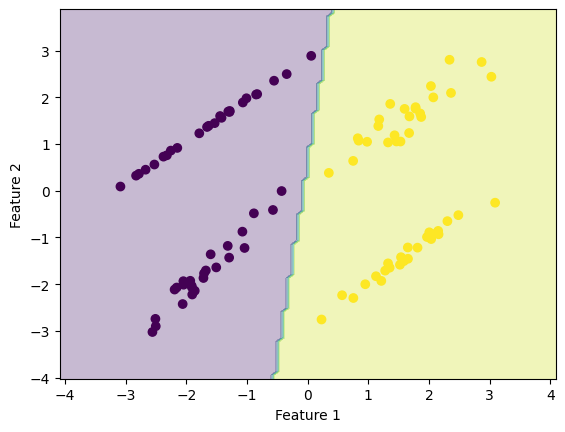

In [32]:
x_min, x_max = X1.iloc[:,0].min()-1, X1.iloc[:,0].max()+1
y_min, y_max = X1.iloc[:,1].min()-1, X1.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = Lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X1.iloc[:,0], X1.iloc[:,1], c=y1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

##Synthetic Dataset for Regression in Python
In scikit-learn, we use `make_regression()` to create artificial datasets for regression problems.

In [33]:
# Import
from sklearn.datasets import make_regression

## Important Parameters

- `n_samples` : Defines the total number of data points (rows) in the dataset. More samples usually help the model learn patterns better.

- `n_features` : Defines the total number of input columns (features). These are the variables used to predict the target.

- `n_informative` : Specifies how many features actually contribute useful information to generate the target. The remaining features may just be noise.

- `noise` : Adds random variation to the target values. Higher noise makes the regression problem harder because points move farther away from the true line.

- `bias` : Adds a constant value to the target. This shifts the regression line upward or downward.

- `effective_rank` : Controls the rank of the input matrix, making features more correlated. Useful for creating more realistic datasets.

- `tail_strength` : Works with `effective_rank` and controls how much noise-like structure appears in the lower singular values.

- `shuffle` : Determines whether the samples and features are randomly shuffled. Usually kept `True`.

- `coef` : If `True`, also returns the true underlying coefficients used to generate the dataset. Useful for understanding the original relationship.

- `random_state` : Fixes randomness so the same dataset is generated every time. Useful for reproducibility.

In [34]:
# Example
X_reg, y_reg = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    noise=10,
    bias=5,
    random_state=42
)


In [37]:
print(X_reg.shape)
print(y_reg.shape)

(100, 1)
(100,)


The `make_regression()` function returns **NumPy arrays** from NumPy.

- `X` is a $2 D$ NumPy array containing the input features.
- `y` is a $1 D$ NumPy array containing the target labels.

In [38]:
type(X_reg),type(y_reg)

(numpy.ndarray, numpy.ndarray)

In [39]:
X_reg.ndim,y_reg.ndim

(2, 1)

##Scatter Plot Visualization

In [40]:
import matplotlib.pyplot as plt

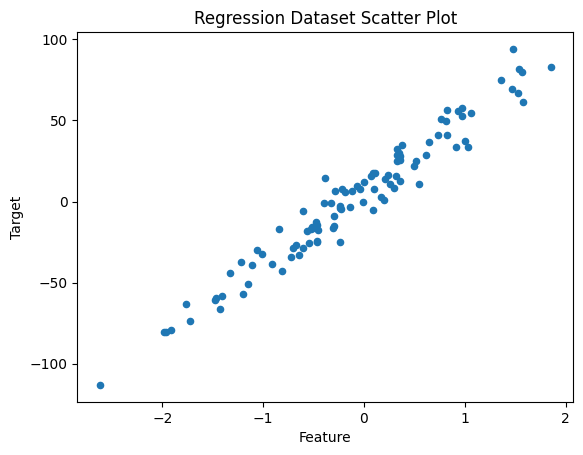

In [41]:
plt.scatter(X_reg, y_reg, s=20)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Regression Dataset Scatter Plot")
plt.show()

##

##Convert into Pandas DataFrame

Although `make_regression()` returns **NumPy arrays**, we often convert them into a **pandas DataFrame** and **Series** for better readability and easier preprocessing.

`Scikit-learn` built-in functions can work with both NumPy arrays and Pandas objects, but Pandas makes feature selection, inspection, and preprocessing easier.

In [44]:
X_reg1=pd.DataFrame(X_reg,columns=["feature"])
y_reg1=pd.Series(y_reg,name="target")

In [45]:
type(X_reg1),type(y_reg1)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

##Convert to CSV File
Once `X` is a pandas DataFrame and `y` is a Series, we can combine them and save them as a **CSV** file.

In [46]:
X_reg1["target"]=y_reg1

In [48]:
X_reg1.head()

,feature,target
0,0.931280,55.779929
1,0.087047,-5.065270
2,-1.057711,-29.918392
3,0.314247,15.526743
4,-0.479174,-12.738377


In [49]:
y_reg1.head()

,target
0,55.779929
1,-5.065270
2,-29.918392
3,15.526743
4,-12.738377


In [51]:
# Save as CSV
X_reg1.to_csv("regression_dataset.csv",index=False)

In [52]:
# load the data
df_reg=pd.read_csv("regression_dataset.csv")

In [54]:
df_reg.head()

,feature,target
0,0.931280,55.779929
1,0.087047,-5.065270
2,-1.057711,-29.918392
3,0.314247,15.526743
4,-0.479174,-12.738377


In [55]:
X_df_reg=df_reg[["feature"]]

In [56]:
y_df_reg=df_reg["target"]

In [57]:
type(X_df_reg),type(y_df_reg)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [58]:
from sklearn.model_selection import train_test_split
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(X_df_reg,y_df_reg,test_size=0.2)

In [59]:
print(x_train_reg.shape[0]==y_train_reg.shape[0])
print(x_test_reg.shape[0]==y_test_reg.shape[0])

True
True


In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
LR=LinearRegression()

In [62]:
LR.fit(x_train_reg,y_train_reg)

LinearRegression()

In [63]:
LR.intercept_

np.float64(5.5704114896170696)

In [64]:
LR.coef_

array([44.74431947])

In [66]:
Y_pred_reg=LR.predict(x_test_reg)

In [67]:
Y_pred_reg

array([ 32.93945077, -49.05540681, -73.31562046,   9.67618499,
       -25.84247643, -11.97420098,  52.8706261 , -60.58504879,
       -16.88036596, -21.35254139,  66.2544486 ,   5.79920963,
        20.94537801,  -9.09060828, -15.43590042,  16.39684867,
       -39.74802773,  27.79554824,  -4.90662191,  71.14986824])

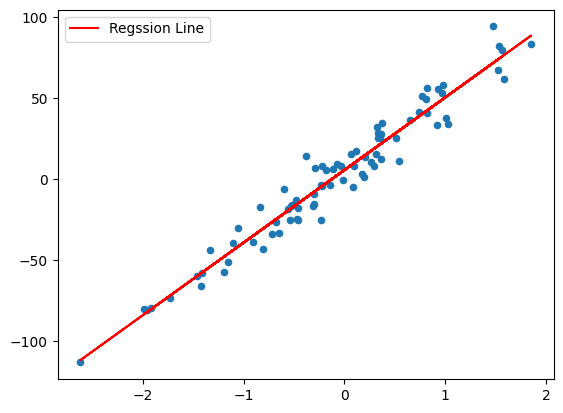

In [70]:
plt.plot(x_train_reg,LR.predict(x_train_reg),color="red",label="Regssion Line")
plt.scatter(x_train_reg,y_train_reg,s=20)
plt.legend()
plt.show()